# delaycp on IEEE-CIS with simulated chargeback delays

A step-by-step version of [`ieee_cis_chargebacks.py`](ieee_cis_chargebacks.py). The steps are the same functions, imported from the script, so the two stay in sync.

**Data.** Download `train_transaction.csv` and `train_identity.csv` from the [Kaggle IEEE-CIS Fraud Detection competition](https://www.kaggle.com/c/ieee-fraud-detection/data) and point `IEEE_CIS_DIR` (or `DATA_DIR` below) at the folder holding them. Install the example dependencies with `uv sync --extra examples` and run the notebook from the `examples/` folder.

In [1]:
import os
from pathlib import Path

import numpy as np

import ieee_cis_chargebacks as ex

DATA_DIR = Path(os.environ.get("IEEE_CIS_DIR", "../data/ieee-cis"))
SEED = 0

## 1. Load, join and split in time

`TransactionDT` is in seconds from an unknown offset, so it is converted to days since the first transaction. The ~182 days split into 121 days of training, 30 of calibration, and a final ~31-day month that is streamed as the test set.

In [2]:
tr, cal, test = ex.split(ex.load(DATA_DIR))
for name, d in [("train", tr), ("calibration", cal), ("test", test)]:
    span = f"days {d.day[0]:5.1f}-{d.day[-1]:5.1f}"
    print(f"{name:<12} {span}  {len(d.y):>7,} rows  {d.y.mean():.2%} fraud")

train        days   0.0-121.0  417,559 rows  3.53% fraud
calibration  days 121.0-151.0   83,655 rows  3.38% fraud
test         days 151.0-182.0   89,326 rows  3.49% fraud


## 2. Train a LightGBM model

The features are the raw transaction columns (amount, card, address, e-mail domain, the `C*` counts, `D*` time deltas and `M*` match flags) plus device type and info. The 339 engineered `V*` columns and the remaining identity columns are left out, and nothing is tuned. Conformal methods treat the model as a black box, so a better model only makes the sets smaller.

The model's scores are very skewed: a tenth of the calibration frauds score below about 0.013, while most legit transactions score below 0.03. To cover 90% of fraud the band must therefore start very low, which is where most of the review volume below comes from.

In [3]:
model = ex.train(tr, SEED)
cal.p, test.p = (np.asarray(model.predict(d.X)) for d in (cal, test))
qs = [0.05, 0.10, 0.50, 0.90, 0.95]
for y, name in [(1, "fraud"), (0, "legit")]:
    q = np.quantile(cal.p[cal.y == y], qs)
    print(f"calibration {name} p_fraud quantiles {qs}:", np.round(q, 4))

calibration fraud p_fraud quantiles [0.05, 0.1, 0.5, 0.9, 0.95]: [0.0067 0.0127 0.191  0.9622 0.9814]
calibration legit p_fraud quantiles [0.05, 0.1, 0.5, 0.9, 0.95]: [0.0009 0.0013 0.0051 0.0292 0.0549]


## 3. Simulate chargeback delays on the test month

A fraud label arrives after a lognormal delay (median 30 days, σ = 0.6) and 10% of frauds are never reported. A legit label is only known once the 60-day maturity window closes without a chargeback. Within the test month, therefore, the online methods see **no** legit labels (`t_high` stays at its calibrated value) and only a small share of the fraud labels, mostly for transactions from the start of the month.

In [4]:
rng = np.random.default_rng(SEED)
label_times = ex.inject_delays(
    test.day,
    test.y,
    "lognormal",
    rng,
    median=ex.CHARGEBACK_MEDIAN,
    sigma=ex.CHARGEBACK_SIGMA,
    p_never=ex.P_NEVER,
    legit_delay=ex.MATURITY,
)
fraud_lt = label_times[test.y == 1]
print(f"fraud labels known by the end of the test month: {np.mean(fraud_lt <= test.day[-1]):.1%}")
print(f"frauds never reported: {np.mean(np.isinf(fraud_lt)):.1%}")

fraud labels known by the end of the test month: 14.9%
frauds never reported: 9.9%


## 4. Compare five decision rules

Every method maps `p_fraud` to APPROVE (`p < t_low`), DECLINE (`p > t_high`) or REVIEW (in between):

| Method | `t_low`, `t_high` |
|---|---|
| Fixed band | Hand-picked: 0.10 and 0.50. |
| Split conformal | One threshold `q` on `s(x, y) = 1 - p̂(y | x)` for both classes (α = 0.05), frozen after calibration. |
| Mondrian split | One threshold per class (α_fraud = 0.10, α_legit = 0.05), frozen after calibration. |
| delaycp coverage | Same targets as Mondrian, updated online from each delayed label, judged against the thresholds in effect when the prediction was made. |
| delaycp budget | `t_high` as above. `t_low` is steered so that 0.5% of transactions go to REVIEW. |

The *(seen)* column is the fraud coverage that could actually be measured at the end of the test month from the labels that had arrived by then.

In [5]:
results = ex.run_methods(cal, test, label_times)
ex.report(test, results, label_times)


Targets: fraud coverage 0.90, legit 0.95; budget mode review rate 0.5%
(seen) = fraud coverage measurable from labels arrived by day 182; worst window = lowest coverage over 300 consecutive frauds

Method             Fraud cov  (seen) Legit cov  Review  Decline Fraud appr. Worst win
-------------------------------------------------------------------------------------
Fixed band             0.567   0.544     0.996   3.45%    1.50%       0.433     0.467
Split conformal        0.160   0.185     0.970   4.25%    0.61%       0.436     0.053
Mondrian split         0.885   0.875     0.939  19.66%    8.22%       0.115     0.843
delaycp coverage       0.901   0.882     0.939  23.71%    8.22%       0.099     0.843
delaycp budget         0.684   0.673     0.939   0.51%    8.22%       0.316     0.613


## 5. Over time

Top: fraud coverage over each window of 300 consecutive frauds. Middle: share of each day's transactions sent to REVIEW. Bottom: the band edges (`t_low` solid, `t_high` dashed). All three use the thresholds each transaction was actually scored with.

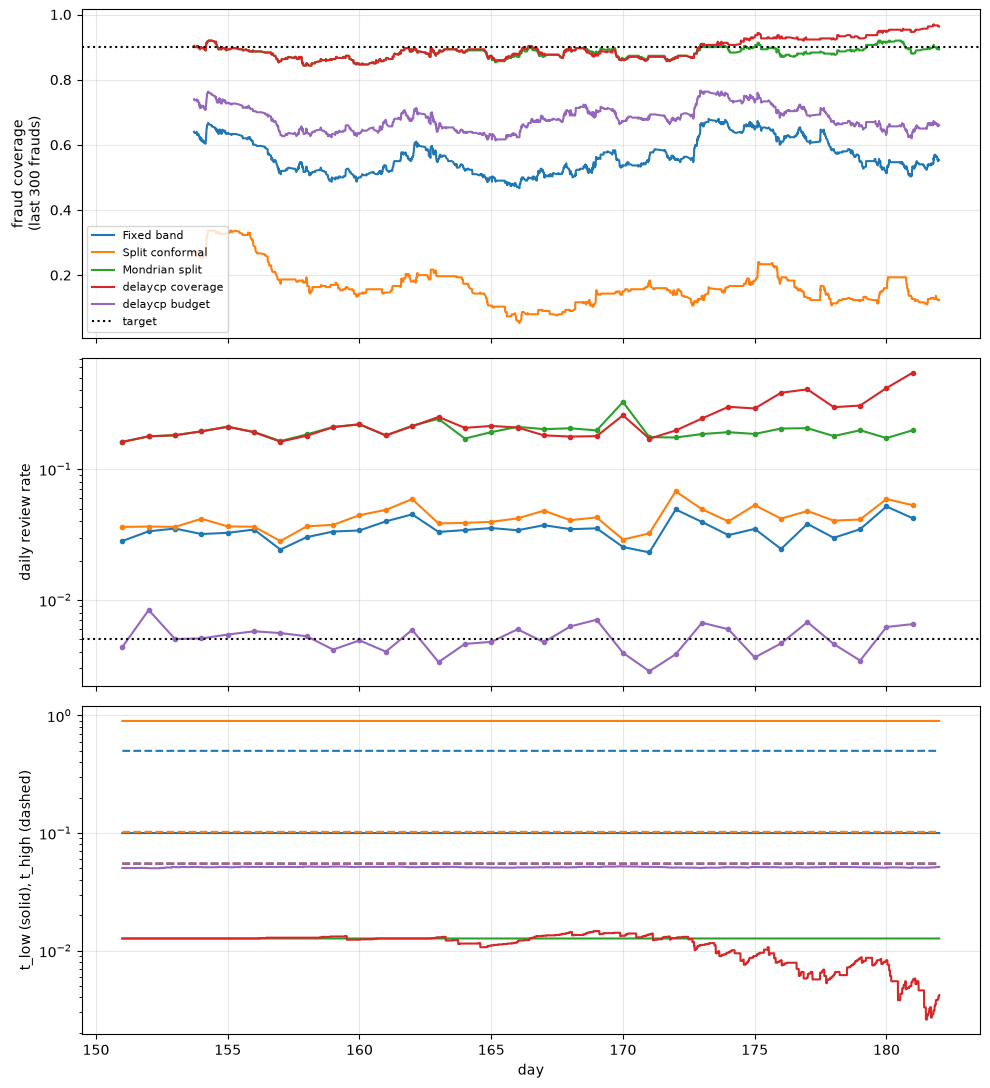

In [6]:
fig = ex.plot(test, results)

## What this shows

- **A fixed band has no coverage guarantee.** With this model the hand-picked band approves over 40% of frauds, so a rule of thumb gives no guide to what the band will actually catch.
- **Marginal (single-threshold) split conformal is the wrong tool for imbalanced classes.** Its 95% coverage target is met almost entirely by the legit class (about 97% of transactions). The threshold puts `t_low` (0.90) above `t_high` (0.10). About 40% of frauds fall between the two and get an empty set: they are sent to REVIEW, but are not covered. Another 44% are approved.
- **Mondrian split conformal gives the per-class guarantee**, as long as the test month looks like the calibration month. Here it lands close to the 0.90 target, at the price of a review rate near 20% with this model.
- **delaycp coverage mode corrects from delayed labels.** In the first half of the month coverage runs slightly below target. Those misses are only reported weeks later, so `t_low` is lowered in the second half, and the month ends at 0.90. Because the evidence lags by the chargeback delay, the tracker keeps correcting after the problem is gone, and late-month coverage overshoots while the review rate climbs. The step size `lr` is in score units and must be small compared to `t_low`, which is about 0.01 here.
- **delaycp budget mode keeps the review queue on budget** (0.5%) from day one, with no labels needed. Fraud coverage then becomes an output, and it drops well below 0.90. Use it when analyst capacity, not missed fraud, is the binding constraint.
- **Delay hides the truth.** At the end of the month only about 15% of that month's fraud labels have arrived, so the *(seen)* coverage is a noisy, lagging estimate of the real one.